# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: End-to-end analytics application using Pyspark

## Problem Statement

Perform sentiment classification by analyzing the tweets data with Pyspark

## Learning Objectives

At the end of the mini-project, you will be able to :

* analyze the text data using pyspark
* derive the insights and visualize the data
* implement feature extraction and classify the data
* train the classification model and deploy

### Dataset

The dataset chosen for this mini-project is **[Twitter US Airline Sentiment](https://data.world/socialmediadata/twitter-us-airline-sentiment)**. It is a record of tweets about airlines in the US. It was created by scraping Twitter data from February 2015. Contributors were asked to first classify positive, negative, and neutral tweets, followed by categorizing negative reasons (such as "late flight" or "rude service").  Along with other information, it contains ID of a Tweet, the sentiment of a tweet ( neutral, negative and positive), reason for a negative tweet, name of airline and text of a tweet.

## Information

The airline industry is a very competitive market that has grown rapidly in the past 2 decades. Airline companies resort to traditional customer feedback forms which in turn are very tedious and time consuming. This is where Twitter data serves as a good source to gather customer feedback tweets and perform sentiment analysis. This dataset comprises of tweets for 6 major US Airlines and a multi-class classification can be performed to categorize the sentiment (neutral, negative, positive). For this mini-project we will start with pre-processing techniques to clean the tweets and then represent these tweets as vectors. A classification algorithm will be used to predict the sentiment for unseen tweets data. The end-to-end analytics will be performed using Pyspark.

## Grading = 10 Points

#### Install Pyspark

In [1]:
#@title Install packages and download the dataset
!pip -qq install pyspark
!pip -qq install handyspark
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/US_Airline_Tweets.csv
print("Packages installed successfully and dataset downloaded!!")

     |████████████████████████████████| 281.3 MB 35 kB/s 
     |████████████████████████████████| 199 kB 60.0 MB/s 
Packages installed successfully and dataset downloaded!!


#### Import required packages

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from handyspark import *
import seaborn as sns
from matplotlib import pyplot as plt
import re
import string
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import CountVectorizer
from pyspark.ml.classification import NaiveBayes
from pyspark.sql.types import ArrayType, StringType
import pandas as pd

In [3]:
# NLTK imports
import nltk
nltk.download('punkt')
# Download stopwords
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


### Data Loading

#### Start a Spark Session

Spark session is a combined entry point of a Spark application, which came into implementation from Spark 2.0. It provides a way to interact with various Spark functionalities, with a lesser number of constructs.

In [4]:
spark = SparkSession.builder.appName('AirlineSentiment').getOrCreate()


#### Load the data and infer the schema

To load the dataset use the `read.csv` with `inferSchema` and `header` as parameters.

In [5]:
path = "/content/US_Airline_Tweets.csv"
dataset = spark.read.csv(path,inferSchema=True,header=True)

In [6]:
dataset.head()

Row(tweet_id='570306133677760513', airline_sentiment='neutral', airline_sentiment_confidence='1.0', negativereason=None, negativereason_confidence=None, airline='Virgin America', airline_sentiment_gold=None, name='cairdin', negativereason_gold=None, retweet_count=0, text='@VirginAmerica What @dhepburn said.', tweet_coord=None, tweet_created='2015-02-24 11:35:52 -0800', tweet_location=None, user_timezone='Eastern Time (US & Canada)')

### EDA & Visualization ( 2 points)

#### Visualize the horizontal barplot of airline_sentiment (positive, negative, neutral)

Convert the data to handyspark and remove the other records from the column except 3 values mentioned above and plot the graph

In [7]:
handy_data = dataset.toHandy()
handy_data

/usr/local/lib/python3.7/dist-packages/pyspark/sql/dataframe.py:149: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  "DataFrame.sql_ctx is an internal property, and will be removed "
/usr/local/lib/python3.7/dist-packages/pyspark/sql/dataframe.py:127: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


HandyFrame[tweet_id: string, airline_sentiment: string, airline_sentiment_confidence: string, negativereason: string, negativereason_confidence: string, airline: string, airline_sentiment_gold: string, name: string, negativereason_gold: string, retweet_count: int, text: string, tweet_coord: string, tweet_created: string, tweet_location: string, user_timezone: string]

In [8]:
df = handy_data.cols[['tweet_id', 'airline_sentiment']][:5]

/usr/local/lib/python3.7/dist-packages/pyspark/sql/dataframe.py:149: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  "DataFrame.sql_ctx is an internal property, and will be removed "
/usr/local/lib/python3.7/dist-packages/pyspark/sql/dataframe.py:127: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


In [9]:
dataset.select('airline_sentiment').groupby('airline_sentiment').agg(count('airline_sentiment')).show(50)

+--------------------+------------------------+
|   airline_sentiment|count(airline_sentiment)|
+--------------------+------------------------+
|[35.23185283, -80...|                       1|
|   ubetter do smth!"|                       1|
|            positive|                    2363|
| we had a good ru...|                       1|
| never submits. F...|                       1|
|[40.7740308, -73....|                       1|
|                   0|                       8|
|     please????????"|                       1|
|                null|                       0|
| this is where Ce...|                       1|
| flight AA1469 2/...|                       1|
|[51.44284934, -0....|                       1|
| or just days tha...|                       1|
|[40.65062011, -73...|                       1|
|             neutral|                    3099|
| this is where Ce...|                       2|
|            negative|                    9178|
| and I might choo...|                  

In [10]:
df_sentiment = dataset.filter((col('airline_sentiment') == 'positive') | (col('airline_sentiment') == 'neutral') | (col('airline_sentiment') == 'negative')).groupby('airline_sentiment').agg(count('airline_sentiment'))

In [11]:
df_sentiment.printSchema()

root
 |-- airline_sentiment: string (nullable = true)
 |-- count(airline_sentiment): long (nullable = false)



In [12]:
pd_df_sentiment = df_sentiment.toPandas()

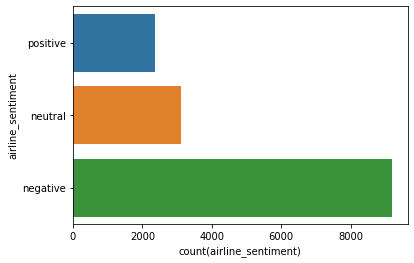

In [13]:
sns.barplot(x="count(airline_sentiment)", y="airline_sentiment", data=pd_df_sentiment)

#### Plot the number of tweets received for each airline

In [14]:
dataset.select('airline').groupby('airline').agg(count('airline')).show()

+--------------------+--------------+
|             airline|count(airline)|
+--------------------+--------------+
|      Rossford, Ohio|             2|
|               Delta|          2222|
|               Quito|             1|
|                null|             0|
|2015-02-22 14:22:...|             1|
|      Virgin America|           504|
|ÜT: 40.96513,-73....|             1|
|              United|          3822|
|       Arlington, VA|             1|
|Eastern Time (US ...|             1|
|Pacific Time (US ...|             2|
|             Arizona|             1|
|          US Airways|          2913|
| Nashville Tennessee|             1|
|    Edmond, Oklahoma|             1|
|           Southwest|          2420|
|Atlantic Highland...|             1|
|             Tijuana|             5|
|            American|          2759|
+--------------------+--------------+



In [15]:
df_airline = dataset.filter((col('airline') == 'Virgin America') | (col('airline') == 'Delta') | (col('airline') == 'US Airways') | (col('airline') == 'Southwest') | (col('airline') == 'American') | (col('airline') == 'United')).groupby('airline').agg(count('airline'))

In [16]:
df_airline.show()

+--------------+--------------+
|       airline|count(airline)|
+--------------+--------------+
|         Delta|          2222|
|Virgin America|           504|
|        United|          3822|
|    US Airways|          2913|
|     Southwest|          2420|
|      American|          2759|
+--------------+--------------+



In [17]:
pd_df_airline = df_airline.toPandas()

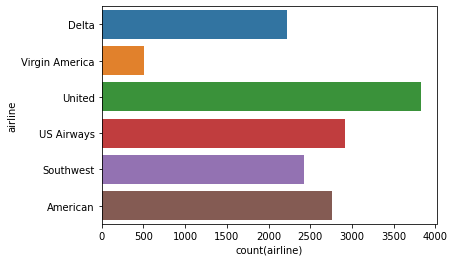

In [18]:
sns.barplot(x="count(airline)", y="airline", data=pd_df_airline)

#### Visualize a stacked barchart of 6 US airlines and 3 sentiments on each bar

* Display the count corresponding to each sentiment in each bar. [hint](https://priteshbgohil.medium.com/stacked-bar-chart-in-python-ddc0781f7d5f)

In [19]:
df_sentiment = dataset.select("airline","airline_sentiment").filter((col('airline_sentiment') == 'positive') | (col('airline_sentiment') == 'neutral') | (col('airline_sentiment') == 'negative'))

In [20]:
df_sentiment.printSchema()

root
 |-- airline: string (nullable = true)
 |-- airline_sentiment: string (nullable = true)



In [21]:
df_airline_sentiment = df_sentiment.filter((col('airline') == 'Virgin America') | (col('airline') == 'Delta') | (col('airline') == 'US Airways') | (col('airline') == 'Southwest') | (col('airline') == 'American') | (col('airline') == 'United'))

In [22]:
df_airline_sentiment_count = df_airline_sentiment.groupby("airline","airline_sentiment").agg(count("*"))

In [23]:
df_airline_sentiment_count.printSchema()

root
 |-- airline: string (nullable = true)
 |-- airline_sentiment: string (nullable = true)
 |-- count(1): long (nullable = false)



In [24]:
pd_df_airline_sentiment = df_airline_sentiment_count.toPandas()

In [25]:
pd_df_airline_sentiment

,airline,airline_sentiment,count(1)
0,Southwest,negative,1186
1,American,negative,1960
2,Virgin America,neutral,171
3,US Airways,neutral,381
4,United,positive,492
5,US Airways,negative,2263
6,American,positive,336
7,Delta,negative,955
8,Virgin America,positive,152
9,Southwest,neutral,664


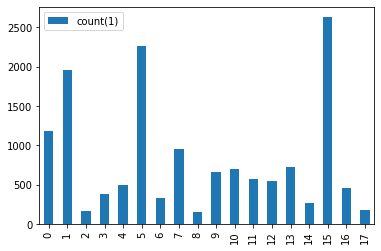

In [26]:
pd_df_airline_sentiment.plot(kind='bar', stacked=True)

#### Visualize the horizontal barplot of negative reasons

In [27]:
df_negative_reason = dataset.groupby('negativereason').agg(count('*'))

In [28]:
pd_df_negative_reason = df_negative_reason.toPandas()

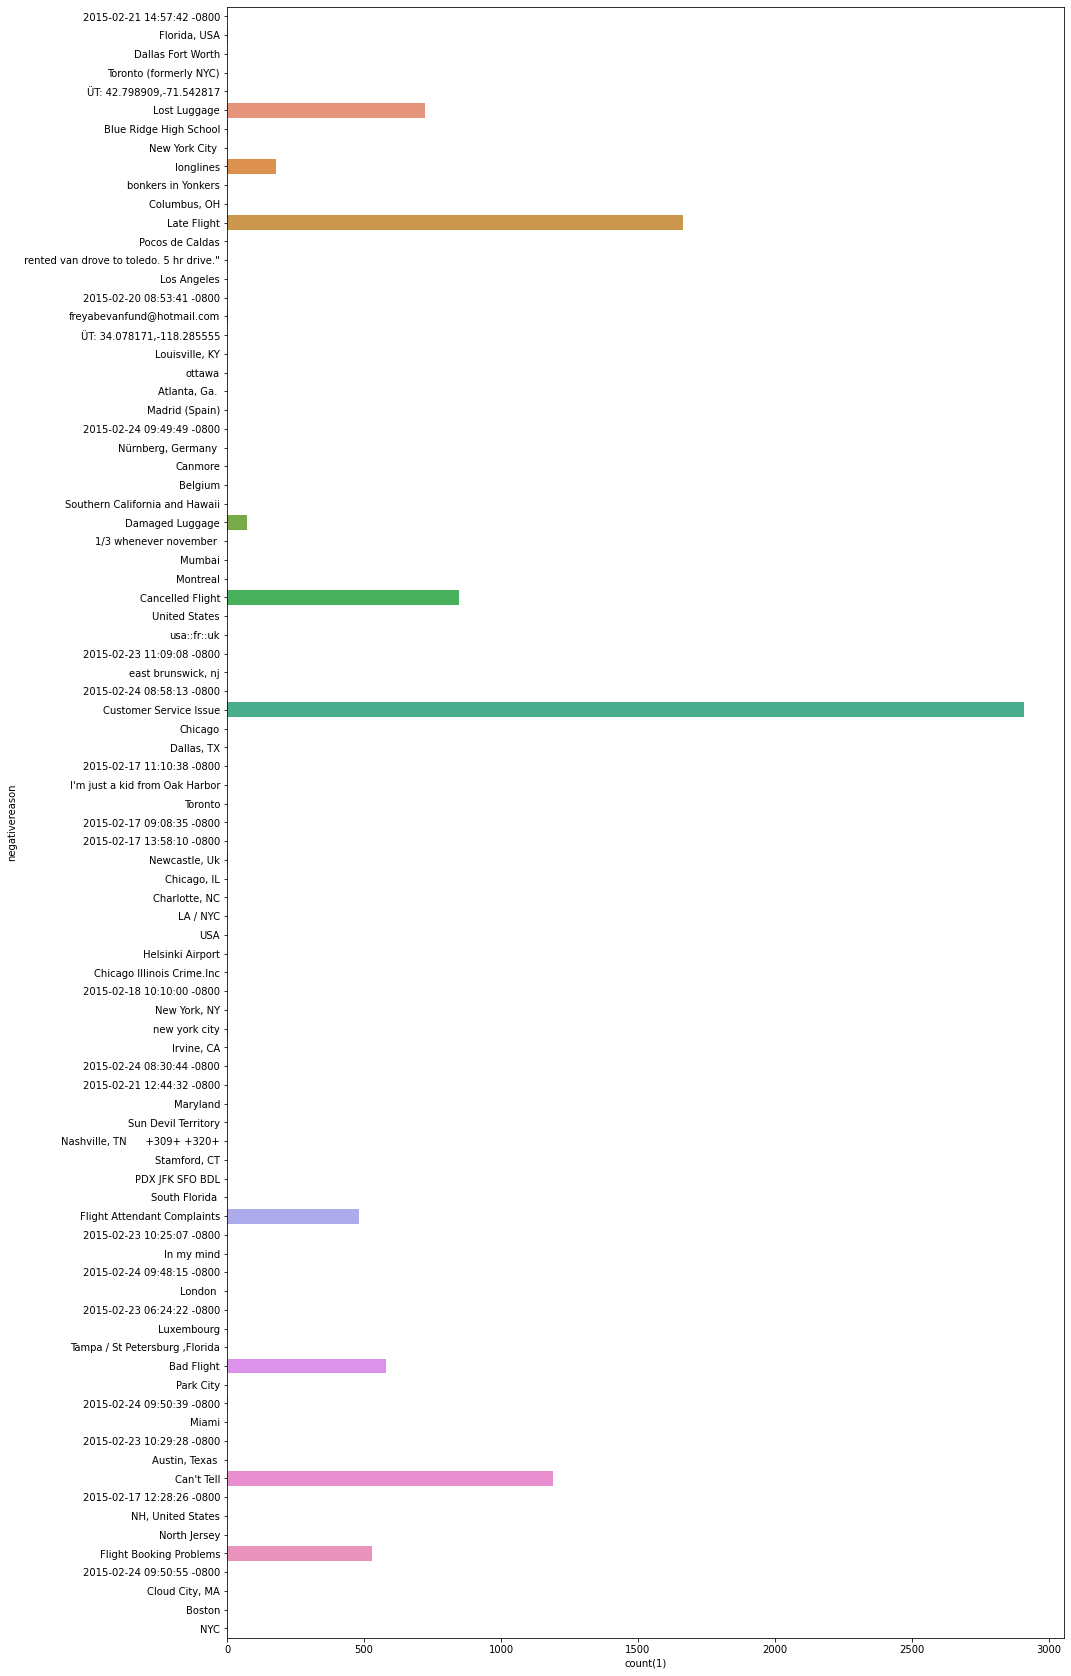

In [29]:
plt.figure(figsize=(15, 30))
sns.barplot(x="count(1)", y="negativereason", data=pd_df_negative_reason)

### Pre-processing (3 points)

#### Check the null values and drop the records where the text value is null

In [30]:
df_sentiment = dataset.filter((col('airline_sentiment') == 'positive') | (col('airline_sentiment') == 'neutral') | (col('airline_sentiment') == 'negative'))


In [31]:
df_airline = df_sentiment.filter((col('airline') == 'Virgin America') | (col('airline') == 'Delta') | (col('airline') == 'US Airways') | (col('airline') == 'Southwest') | (col('airline') == 'American') | (col('airline') == 'United'))

In [32]:
pandas_full_df = df_airline.toPandas()

In [33]:
len(pandas_full_df)

14640

In [34]:
pandas_full_df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0,None,None,Virgin America,None,cairdin,None,0.0,@VirginAmerica What @dhepburn said.,None,2015-02-24 11:35:52 -0800,None,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,None,0.0,Virgin America,None,jnardino,None,0.0,@VirginAmerica plus you've added commercials t...,None,2015-02-24 11:15:59 -0800,None,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,None,None,Virgin America,None,yvonnalynn,None,0.0,@VirginAmerica I didn't today... Must mean I n...,None,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0,Bad Flight,0.7033,Virgin America,None,jnardino,None,0.0,"""@VirginAmerica it's really aggressive to blas...",None,2015-02-24 11:15:36 -0800,None,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0,Can't Tell,1.0,Virgin America,None,jnardino,None,0.0,@VirginAmerica and it's a really big bad thing...,None,2015-02-24 11:14:45 -0800,None,Pacific Time (US & Canada)


In [35]:
import numpy as np
pandas_full_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [36]:
pandas_full_df.isna().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       8
text                                8
tweet_coord                     13571
tweet_created                     192
tweet_location                   4813
user_timezone                    4906
dtype: int64

In [37]:
pandas_full_df.drop(columns=['negativereason','airline_sentiment_gold','negativereason_confidence','negativereason_gold','tweet_coord','tweet_location','user_timezone'],inplace=True)

In [38]:
pandas_full_df.isna().sum()

tweet_id                          0
airline_sentiment                 0
airline_sentiment_confidence      0
airline                           0
name                              0
retweet_count                     8
text                              8
tweet_created                   192
dtype: int64

#### Fill the null values with 0 in all the columns except the target

The target should not be empty. Ensure that all features are integer type, convert if needed.

In [39]:
pandas_full_df = pandas_full_df.fillna(0)

In [40]:
pandas_full_df.isna().sum()

tweet_id                        0
airline_sentiment               0
airline_sentiment_confidence    0
airline                         0
name                            0
retweet_count                   0
text                            0
tweet_created                   0
dtype: int64

In [41]:
len(pandas_full_df)

14640

#### Preprocessing and cleaning the tweets

* Convert the text to lower case
* Remove usernames, hashtags and links from the text (tweets)

In [42]:
pandas_full_df.text[2]

"@VirginAmerica I didn't today... Must mean I need to take another trip!"

In [43]:
pandas_full_df['text']=pandas_full_df['text'].str.lower()
pandas_full_df['text']

0                      @virginamerica what @dhepburn said.
1        @virginamerica plus you've added commercials t...
2        @virginamerica i didn't today... must mean i n...
3        "@virginamerica it's really aggressive to blas...
4        @virginamerica and it's a really big bad thing...
                               ...                        
14635    @americanair thank you we got on a different f...
14636    @americanair leaving over 20 minutes late flig...
14637    @americanair please bring american airlines to...
14638    @americanair you have my money, you change my ...
14639    @americanair we have 8 ppl so we need 2 know h...
Name: text, Length: 14640, dtype: object

In [44]:
import re
def cleanTweet(tweetText):
    tweetText = re.sub("[^a-zA-Z]"," ", tweetText) # Replace non letters with spaces
    tweetText = re.sub('http\S+\s*', ' ', tweetText)  # remove URLs
    tweetText = re.sub('#\S+', '', tweetText)  # remove hashtags
    tweetText = re.sub('@\S+', '  ', tweetText)  # remove mentions
    tweetText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', tweetText)  # remove punctuations
    #tweetText = re.sub(r'[^\x00-\x7f]',r' ', tweetText) 
    tweetText = re.sub('\s+', ' ', tweetText)  # remove extra whitespace
    return tweetText

In [45]:
pandas_full_df['cleaned_tweet'] = pandas_full_df.text.apply(str).apply(lambda x: cleanTweet(x))

In [46]:
pandas_full_df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,airline,name,retweet_count,text,tweet_created,cleaned_tweet
0,570306133677760513,neutral,1.0,Virgin America,cairdin,0.0,@virginamerica what @dhepburn said.,2015-02-24 11:35:52 -0800,virginamerica what dhepburn said
1,570301130888122368,positive,0.3486,Virgin America,jnardino,0.0,@virginamerica plus you've added commercials t...,2015-02-24 11:15:59 -0800,virginamerica plus you ve added commercials t...
2,570301083672813571,neutral,0.6837,Virgin America,yvonnalynn,0.0,@virginamerica i didn't today... must mean i n...,2015-02-24 11:15:48 -0800,virginamerica i didn t today must mean i need...
3,570301031407624196,negative,1.0,Virgin America,jnardino,0.0,"""@virginamerica it's really aggressive to blas...",2015-02-24 11:15:36 -0800,virginamerica it s really aggressive to blast...
4,570300817074462722,negative,1.0,Virgin America,jnardino,0.0,@virginamerica and it's a really big bad thing...,2015-02-24 11:14:45 -0800,virginamerica and it s a really big bad thing...


In [47]:
pandas_full_df = pandas_full_df.drop(columns=['tweet_id','airline','name','tweet_created'])

In [48]:
pandas_full_df.head()

,airline_sentiment,airline_sentiment_confidence,retweet_count,text,cleaned_tweet
0,neutral,1.0,0.0,@virginamerica what @dhepburn said.,virginamerica what dhepburn said
1,positive,0.3486,0.0,@virginamerica plus you've added commercials t...,virginamerica plus you ve added commercials t...
2,neutral,0.6837,0.0,@virginamerica i didn't today... must mean i n...,virginamerica i didn t today must mean i need...
3,negative,1.0,0.0,"""@virginamerica it's really aggressive to blas...",virginamerica it s really aggressive to blast...
4,negative,1.0,0.0,@virginamerica and it's a really big bad thing...,virginamerica and it s a really big bad thing...


#### Tokenize each sentence into words using nltk word tokenizer

In [49]:
pandas_full_df['cleaned_tweet_tokenized'] = pandas_full_df.cleaned_tweet.apply(lambda x: word_tokenize(x))
pandas_full_df.head()

,airline_sentiment,airline_sentiment_confidence,retweet_count,text,cleaned_tweet,cleaned_tweet_tokenized
0,neutral,1.0,0.0,@virginamerica what @dhepburn said.,virginamerica what dhepburn said,"[virginamerica, what, dhepburn, said]"
1,positive,0.3486,0.0,@virginamerica plus you've added commercials t...,virginamerica plus you ve added commercials t...,"[virginamerica, plus, you, ve, added, commerci..."
2,neutral,0.6837,0.0,@virginamerica i didn't today... must mean i n...,virginamerica i didn t today must mean i need...,"[virginamerica, i, didn, t, today, must, mean,..."
3,negative,1.0,0.0,"""@virginamerica it's really aggressive to blas...",virginamerica it s really aggressive to blast...,"[virginamerica, it, s, really, aggressive, to,..."
4,negative,1.0,0.0,@virginamerica and it's a really big bad thing...,virginamerica and it s a really big bad thing...,"[virginamerica, and, it, s, a, really, big, ba..."


#### Remove the stopwords from tokenized words

In [50]:
stop_words = set(stopwords.words('english'))
print(stop_words)

{'during', 'and', 'on', 'how', 'theirs', 'such', 'because', 'who', 'is', 'yourselves', 'do', 'won', "wasn't", "doesn't", 'these', 'ourselves', 'wouldn', 'more', 'few', 't', 'am', 'll', 'own', 'now', 'hasn', 'myself', 'our', 'same', 'than', 'doing', 'their', 'about', 'each', "weren't", "don't", 'ours', 'itself', 'themselves', 'hadn', "you'll", 'in', "should've", 'o', 'further', 'under', 'ma', 'here', 'most', 'of', 'that', 'when', "hadn't", "mustn't", 'shan', 'ain', 'needn', 'did', 'be', 'if', 'into', 'this', 'again', 'where', 'been', 'those', 'other', 'will', 'her', 'from', 'whom', "haven't", 'above', 'd', 'some', 'or', "couldn't", 'aren', 'my', 'was', 'him', 'a', 'after', 'couldn', 'at', 'very', 'have', 'as', 'there', 'nor', 'so', "wouldn't", 're', 'himself', 'before', 'it', "needn't", "hasn't", 'over', 'off', "isn't", "didn't", 'has', 'down', "it's", 'me', 'having', 'yourself', "you've", 'why', 'the', 'no', 'then', 'didn', 'isn', 'had', 'were', 'y', 'he', 'but', 'wasn', 'yours', 'them

In [51]:
# https://stackoverflow.com/questions/29523254/python-remove-stop-words-from-pandas-dataframe
#pandas_full_df['cleaned_tweet_tokenized_no_stopwords'] = pandas_full_df['cleaned_tweet_tokenized'].apply(lambda x: ' '.join(word for word in x.str.split(' ') if word not in (stop_words)))
pandas_full_df['cleaned_tweet_tokenized_no_stopwords'] = pandas_full_df['cleaned_tweet_tokenized'].apply(lambda x: ' '.join([word for word in x if word not in stop_words]))

In [52]:
pandas_full_df.head()

,airline_sentiment,airline_sentiment_confidence,retweet_count,text,cleaned_tweet,cleaned_tweet_tokenized,cleaned_tweet_tokenized_no_stopwords
0,neutral,1.0,0.0,@virginamerica what @dhepburn said.,virginamerica what dhepburn said,"[virginamerica, what, dhepburn, said]",virginamerica dhepburn said
1,positive,0.3486,0.0,@virginamerica plus you've added commercials t...,virginamerica plus you ve added commercials t...,"[virginamerica, plus, you, ve, added, commerci...",virginamerica plus added commercials experienc...
2,neutral,0.6837,0.0,@virginamerica i didn't today... must mean i n...,virginamerica i didn t today must mean i need...,"[virginamerica, i, didn, t, today, must, mean,...",virginamerica today must mean need take anothe...
3,negative,1.0,0.0,"""@virginamerica it's really aggressive to blas...",virginamerica it s really aggressive to blast...,"[virginamerica, it, s, really, aggressive, to,...",virginamerica really aggressive blast obnoxiou...
4,negative,1.0,0.0,@virginamerica and it's a really big bad thing...,virginamerica and it s a really big bad thing...,"[virginamerica, and, it, s, a, really, big, ba...",virginamerica really big bad thing


#### Apply Lemmatization to the words

In [53]:
lemmatizer = nltk.stem.WordNetLemmatizer()

def lemmatize_text(text):
    return lemmatizer.lemmatize(text)

In [54]:
nltk.download('omw-1.4')
pandas_full_df['lemmatized'] = pandas_full_df.cleaned_tweet_tokenized_no_stopwords.apply(lemmatize_text)

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [55]:
pandas_full_df.head()

,airline_sentiment,airline_sentiment_confidence,retweet_count,text,cleaned_tweet,cleaned_tweet_tokenized,cleaned_tweet_tokenized_no_stopwords,lemmatized
0,neutral,1.0,0.0,@virginamerica what @dhepburn said.,virginamerica what dhepburn said,"[virginamerica, what, dhepburn, said]",virginamerica dhepburn said,virginamerica dhepburn said
1,positive,0.3486,0.0,@virginamerica plus you've added commercials t...,virginamerica plus you ve added commercials t...,"[virginamerica, plus, you, ve, added, commerci...",virginamerica plus added commercials experienc...,virginamerica plus added commercials experienc...
2,neutral,0.6837,0.0,@virginamerica i didn't today... must mean i n...,virginamerica i didn t today must mean i need...,"[virginamerica, i, didn, t, today, must, mean,...",virginamerica today must mean need take anothe...,virginamerica today must mean need take anothe...
3,negative,1.0,0.0,"""@virginamerica it's really aggressive to blas...",virginamerica it s really aggressive to blast...,"[virginamerica, it, s, really, aggressive, to,...",virginamerica really aggressive blast obnoxiou...,virginamerica really aggressive blast obnoxiou...
4,negative,1.0,0.0,@virginamerica and it's a really big bad thing...,virginamerica and it s a really big bad thing...,"[virginamerica, and, it, s, a, really, big, ba...",virginamerica really big bad thing,virginamerica really big bad thing


### Feature Extraction (3 points)

Create the useful features from the text column to train the model

For example:
* Length of the tweet 
* No. of hashtags in the tweet starting with '#'
* No. of mentions in the tweet starting with '@'

Hint: create a new column for each of the above features

In [56]:
pandas_full_df['tweet_length'] = pandas_full_df.lemmatized.str.len()

In [57]:
pandas_full_df.head()

,airline_sentiment,airline_sentiment_confidence,retweet_count,text,cleaned_tweet,cleaned_tweet_tokenized,cleaned_tweet_tokenized_no_stopwords,lemmatized,tweet_length
0,neutral,1.0,0.0,@virginamerica what @dhepburn said.,virginamerica what dhepburn said,"[virginamerica, what, dhepburn, said]",virginamerica dhepburn said,virginamerica dhepburn said,27
1,positive,0.3486,0.0,@virginamerica plus you've added commercials t...,virginamerica plus you ve added commercials t...,"[virginamerica, plus, you, ve, added, commerci...",virginamerica plus added commercials experienc...,virginamerica plus added commercials experienc...,53
2,neutral,0.6837,0.0,@virginamerica i didn't today... must mean i n...,virginamerica i didn t today must mean i need...,"[virginamerica, i, didn, t, today, must, mean,...",virginamerica today must mean need take anothe...,virginamerica today must mean need take anothe...,52
3,negative,1.0,0.0,"""@virginamerica it's really aggressive to blas...",virginamerica it s really aggressive to blast...,"[virginamerica, it, s, really, aggressive, to,...",virginamerica really aggressive blast obnoxiou...,virginamerica really aggressive blast obnoxiou...,94
4,negative,1.0,0.0,@virginamerica and it's a really big bad thing...,virginamerica and it s a really big bad thing...,"[virginamerica, and, it, s, a, really, big, ba...",virginamerica really big bad thing,virginamerica really big bad thing,34


In [58]:
pandas_full_df['hashtags'] = pandas_full_df.text.str.count('#')

In [59]:
pandas_full_df['mentions'] = pandas_full_df.text.str.count('@')

In [60]:
pandas_full_df.head()

,airline_sentiment,airline_sentiment_confidence,retweet_count,text,cleaned_tweet,cleaned_tweet_tokenized,cleaned_tweet_tokenized_no_stopwords,lemmatized,tweet_length,hashtags,mentions
0,neutral,1.0,0.0,@virginamerica what @dhepburn said.,virginamerica what dhepburn said,"[virginamerica, what, dhepburn, said]",virginamerica dhepburn said,virginamerica dhepburn said,27,0.0,2.0
1,positive,0.3486,0.0,@virginamerica plus you've added commercials t...,virginamerica plus you ve added commercials t...,"[virginamerica, plus, you, ve, added, commerci...",virginamerica plus added commercials experienc...,virginamerica plus added commercials experienc...,53,0.0,1.0
2,neutral,0.6837,0.0,@virginamerica i didn't today... must mean i n...,virginamerica i didn t today must mean i need...,"[virginamerica, i, didn, t, today, must, mean,...",virginamerica today must mean need take anothe...,virginamerica today must mean need take anothe...,52,0.0,1.0
3,negative,1.0,0.0,"""@virginamerica it's really aggressive to blas...",virginamerica it s really aggressive to blast...,"[virginamerica, it, s, really, aggressive, to,...",virginamerica really aggressive blast obnoxiou...,virginamerica really aggressive blast obnoxiou...,94,0.0,1.0
4,negative,1.0,0.0,@virginamerica and it's a really big bad thing...,virginamerica and it s a really big bad thing...,"[virginamerica, and, it, s, a, really, big, ba...",virginamerica really big bad thing,virginamerica really big bad thing,34,0.0,1.0


#### Get the features by applying CountVectorizer
CountVectorizer converts the list of tokens to vectors of token counts. See the [documentation](https://spark.apache.org/docs/latest/ml-features.html#countvectorizer) for details.

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features = 1500)
to_vectorize_text = pandas_full_df['lemmatized'].values
vectorized_text = vectorizer.fit_transform(to_vectorize_text)

In [62]:
vectorized_text

<14640x1500 sparse matrix of type '<class 'numpy.float64'>'
	with 116734 stored elements in Compressed Sparse Row format>

In [63]:
#vectorizer = CountVectorizer()
#to_vectorize_text = pandas_full_df['lemmatized'].values
#vectorizer.fit(to_vectorize_text)

#vectorized_text = vectorizer.fit_transform(pandas_full_df['cleaned_tweet_tokenized'])
#vectorized_text = vectorizer.transform(to_vectorize_text)

In [64]:
vectorized_text

<14640x1500 sparse matrix of type '<class 'numpy.float64'>'
	with 116734 stored elements in Compressed Sparse Row format>

#### Encode the labels

Using the `udf` function encode the string values of *airline_sentiment* to integers.

In [65]:
def LabelEncoder(x):
    if x == 'positive':
        return 0
    elif x == 'negative':
        return 1
    return 2

pandas_full_df['airline_sentiment'] = pandas_full_df['airline_sentiment'].apply(LabelEncoder)

In [66]:
pandas_full_df.head()

,airline_sentiment,airline_sentiment_confidence,retweet_count,text,cleaned_tweet,cleaned_tweet_tokenized,cleaned_tweet_tokenized_no_stopwords,lemmatized,tweet_length,hashtags,mentions
0,2,1.0,0.0,@virginamerica what @dhepburn said.,virginamerica what dhepburn said,"[virginamerica, what, dhepburn, said]",virginamerica dhepburn said,virginamerica dhepburn said,27,0.0,2.0
1,0,0.3486,0.0,@virginamerica plus you've added commercials t...,virginamerica plus you ve added commercials t...,"[virginamerica, plus, you, ve, added, commerci...",virginamerica plus added commercials experienc...,virginamerica plus added commercials experienc...,53,0.0,1.0
2,2,0.6837,0.0,@virginamerica i didn't today... must mean i n...,virginamerica i didn t today must mean i need...,"[virginamerica, i, didn, t, today, must, mean,...",virginamerica today must mean need take anothe...,virginamerica today must mean need take anothe...,52,0.0,1.0
3,1,1.0,0.0,"""@virginamerica it's really aggressive to blas...",virginamerica it s really aggressive to blast...,"[virginamerica, it, s, really, aggressive, to,...",virginamerica really aggressive blast obnoxiou...,virginamerica really aggressive blast obnoxiou...,94,0.0,1.0
4,1,1.0,0.0,@virginamerica and it's a really big bad thing...,virginamerica and it s a really big bad thing...,"[virginamerica, and, it, s, a, really, big, ba...",virginamerica really big bad thing,virginamerica really big bad thing,34,0.0,1.0


### Train the classifier the evaluate (1 point)

#### Create vector assembler with the selected features to train the model

In [67]:
y = pandas_full_df.airline_sentiment
y

0        2
1        0
2        2
3        1
4        1
        ..
14635    0
14636    1
14637    2
14638    1
14639    2
Name: airline_sentiment, Length: 14640, dtype: int64

In [68]:
pandas_full_df.drop(columns=['text','cleaned_tweet','cleaned_tweet_tokenized','cleaned_tweet_tokenized_no_stopwords','lemmatized'],inplace=True)

In [69]:
pandas_full_df.head()

,airline_sentiment,airline_sentiment_confidence,retweet_count,tweet_length,hashtags,mentions
0,2,1.0,0.0,27,0.0,2.0
1,0,0.3486,0.0,53,0.0,1.0
2,2,0.6837,0.0,52,0.0,1.0
3,1,1.0,0.0,94,0.0,1.0
4,1,1.0,0.0,34,0.0,1.0


In [70]:
X = pandas_full_df
X.drop(columns=['airline_sentiment'],inplace=True)

In [71]:
X.head()

,airline_sentiment_confidence,retweet_count,tweet_length,hashtags,mentions
0,1.0,0.0,27,0.0,2.0
1,0.3486,0.0,53,0.0,1.0
2,0.6837,0.0,52,0.0,1.0
3,1.0,0.0,94,0.0,1.0
4,1.0,0.0,34,0.0,1.0


In [72]:
pd_df_tfidf = pd.DataFrame(vectorized_text.toarray(), columns=vectorizer.get_feature_names())

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [94]:
pd_df_result = pd.concat([X, pd_df_tfidf], axis=1)

In [74]:
pd_df_result.head()

,airline_sentiment_confidence,retweet_count,tweet_length,hashtags,mentions,aa,able,absolute,absolutely,absurd,...,years,yep,yes,yesterday,yet,yo,york,yr,yyz,zero
0,1.0,0.0,27,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.3486,0.0,53,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.6837,0.0,52,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,94,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,34,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [95]:
pd_df_result = pd_df_result.astype(float)

In [90]:
#pd_df_result = pd_df_result.replace('',np.nan).astype(float)

In [96]:
pd_df_result = pd_df_result.replace(np.nan, 0, regex=True)

#### Arrange features and label and split them into train and test.

In [97]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(pd_df_result,y,random_state=0, test_size=0.2)

#### Train the model with train data and make predictions on the test data

For classification of text data, implement NaiveBayes classifier. It is a probabilistic machine learning model.

For more information about **NaiveBayes Classifier**, click [here](https://spark.apache.org/docs/latest/ml-classification-regression.html#naive-bayes)

In [98]:
from sklearn.naive_bayes import MultinomialNB
clf = MultinomialNB()

In [99]:
clf.fit(X_train, y_train)

MultinomialNB()

In [ ]:
#nb = NaiveBayes(featuresCol='features', labelCol='labels')
# Fit the model with train data
#model = nb.fit(train_data)

In [ ]:
# get the predictions
pred = clf.predict(X_test)

#### Evaluate the model and find the accuracy

Compare the labels and predictions and find how many are correct.

To find the accuracy, get the count of correct predictions from test data and divide by the total amount of test dataset.

**Hint:** convert the predictions dataframe to pandas and compare with labels

In [101]:
print('Accuracy of NaiveBayes Classifier on training set: {:.2f}'.format(clf.score(X_train, y_train)))

Accuracy of NaiveBayes Classifier on training set: 0.78


In [105]:
print('Accuracy of NaiveBayes Classifier on test set: {:.2f}'.format(clf.score(X_test, y_test)))

Accuracy of NaiveBayes Classifier on test set: 0.76


In [104]:
from sklearn import metrics
from sklearn.metrics import accuracy_score
print("\n Classification report for classifier %s:\n%s\n" % (clf, metrics.classification_report(y_test, pred)))


 Classification report for classifier MultinomialNB():
              precision    recall  f1-score   support

           0       0.83      0.42      0.56       444
           1       0.76      0.97      0.85      1870
           2       0.71      0.35      0.46       614

    accuracy                           0.76      2928
   macro avg       0.77      0.58      0.62      2928
weighted avg       0.76      0.76      0.73      2928




### Deployment (1 point)

Let's integrate all the above code snippets in app.py and run it with **Streamlit**.

From the start (data loading step), place every code in app.py including data preprocessing, feature extraction and model training.

* implement the `predict_users_Input()` function which takes one tweet input from user and returns the prediction using the trained model.

* use the same preprocessing techniques and features extraction used for train data on user input.

* user input can be captured from the textbox from **Streamlit** app. Action is triggered when predict button is clicked and user input is classified using `predict_users_Input()` function.


For More information about Streamlit, click [here](https://docs.streamlit.io/en/stable/)

In [111]:
# Install streamlit and colab-everything
!pip install -qq streamlit

     |████████████████████████████████| 9.1 MB 5.2 MB/s 
     |████████████████████████████████| 164 kB 53.7 MB/s 
     |████████████████████████████████| 235 kB 60.5 MB/s 
     |████████████████████████████████| 78 kB 5.9 MB/s 
     |████████████████████████████████| 4.3 MB 47.9 MB/s 
     |████████████████████████████████| 111 kB 59.1 MB/s 
     |████████████████████████████████| 181 kB 64.7 MB/s 
     |████████████████████████████████| 63 kB 1.7 MB/s 
     |████████████████████████████████| 132 kB 59.9 MB/s 
     |████████████████████████████████| 423 kB 43.4 MB/s 
     |████████████████████████████████| 793 kB 59.8 MB/s 
     |████████████████████████████████| 132 kB 51.7 MB/s 
     |████████████████████████████████| 381 kB 64.3 MB/s 
     |████████████████████████████████| 51 kB 7.1 MB/s 
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nbclient 0.6.6 requi

Create the `app.py` file and run with Streamlit

**Note:** We have provided the required code to execute Streamlit.

In [194]:
%%writefile app.py
import streamlit as st
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import re
import string
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import CountVectorizer
from pyspark.ml.classification import NaiveBayes
from pyspark.sql.types import ArrayType, StringType
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import numpy as np
import pandas as pd

st.write("Creating a spark session")
spark = SparkSession.builder.appName('TwitterSentiment').getOrCreate()
dataset = spark.read.csv("/content/US_Airline_Tweets.csv",inferSchema=True,header=True)

st.write("Preprocessing the train data")
# 1. Data preprocessing (PASTE YOUR ENTIRE DATA PREPROCESSING CODE FROM ABOVE)
df_sentiment = dataset.filter((col('airline_sentiment') == 'positive') | (col('airline_sentiment') == 'neutral') | (col('airline_sentiment') == 'negative'))

df_airline = df_sentiment.filter((col('airline') == 'Virgin America') | (col('airline') == 'Delta') | (col('airline') == 'US Airways') | (col('airline') == 'Southwest') | (col('airline') == 'American') | (col('airline') == 'United'))

pandas_full_df = df_airline.toPandas()

pandas_full_df.replace([np.inf, -np.inf], np.nan, inplace=True)

pandas_full_df.drop(columns=['airline_sentiment_confidence','retweet_count','negativereason','airline_sentiment_gold','negativereason_confidence','negativereason_gold','tweet_coord','tweet_location','user_timezone'],inplace=True)

pandas_full_df = pandas_full_df.fillna(0)

pandas_full_df['text']=pandas_full_df['text'].str.lower()

import re
def cleanTweet(tweetText):
    tweetText = re.sub("[^a-zA-Z]"," ", tweetText) # Replace non letters with spaces
    tweetText = re.sub('http\S+\s*', ' ', tweetText)  # remove URLs
    tweetText = re.sub('#\S+', '', tweetText)  # remove hashtags
    tweetText = re.sub('@\S+', '  ', tweetText)  # remove mentions
    tweetText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', tweetText)  # remove punctuations
    #tweetText = re.sub(r'[^\x00-\x7f]',r' ', tweetText) 
    tweetText = re.sub('\s+', ' ', tweetText)  # remove extra whitespace
    return tweetText

pandas_full_df['cleaned_tweet'] = pandas_full_df.text.apply(str).apply(lambda x: cleanTweet(x))

pandas_full_df = pandas_full_df.drop(columns=['tweet_id','airline','name','tweet_created'])


st.write("Ongoing feature extraction!!")
# 2. Feature Extraction (PASTE YOUR ENTIRE FEATURE EXTRACTION CODE FROM ABOVE)
pandas_full_df['cleaned_tweet_tokenized'] = pandas_full_df.cleaned_tweet.apply(lambda x: word_tokenize(x))

stop_words = set(stopwords.words('english'))

pandas_full_df['cleaned_tweet_tokenized_no_stopwords'] = pandas_full_df['cleaned_tweet_tokenized'].apply(lambda x: ' '.join([word for word in x if word not in stop_words]))

lemmatizer = nltk.stem.WordNetLemmatizer()

def lemmatize_text(text):
    return lemmatizer.lemmatize(text)

nltk.download('omw-1.4')
pandas_full_df['lemmatized'] = pandas_full_df.cleaned_tweet_tokenized_no_stopwords.apply(lemmatize_text)

pandas_full_df['tweet_length'] = pandas_full_df.lemmatized.str.len()

pandas_full_df['hashtags'] = pandas_full_df.text.str.count('#')

pandas_full_df['mentions'] = pandas_full_df.text.str.count('@')

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features = 1500)
to_vectorize_text = pandas_full_df['lemmatized'].values
vectorized_text = vectorizer.fit_transform(to_vectorize_text)

def LabelEncoder(x):
    if x == 'positive':
        return 0
    elif x == 'negative':
        return 1
    return 2

pandas_full_df['airline_sentiment'] = pandas_full_df['airline_sentiment'].apply(LabelEncoder)
y = pandas_full_df.airline_sentiment

pandas_full_df.drop(columns=['airline_sentiment','text','cleaned_tweet','cleaned_tweet_tokenized','cleaned_tweet_tokenized_no_stopwords','lemmatized'],inplace=True)

X = pandas_full_df

pd_df_tfidf = pd.DataFrame(vectorized_text.toarray(), columns=vectorizer.get_feature_names())

pd_df_result = pd.concat([X, pd_df_tfidf], axis=1)

pd_df_result = pd_df_result.astype(float)
pd_df_result = pd_df_result.replace(np.nan, 0, regex=True)

st.write("Training the model")
# 3. Training the model (PASTE YOUR MODEL TRAINING CODE FROM ABOVE)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(pd_df_result,y,random_state=0, test_size=0.01)

from sklearn.naive_bayes import MultinomialNB
clf = MultinomialNB()

clf.fit(X_train, y_train)

st.write("X_train = \n", X_train.head())
def predict_users_Input(user_input):
  df1 = spark.createDataFrame([ (1, user_input)],['Id', 'UserTweet'])

  # YOUR CODE HERE for data preprocessing and feature extraction for user input data
  pandas_user_df = df1.toPandas()
  pandas_user_df['UserTweet'] = pandas_user_df['UserTweet'].str.lower()
  pandas_user_df['cleaned_tweet'] = pandas_user_df.UserTweet.apply(str).apply(lambda x: cleanTweet(x))
  pandas_user_df = pandas_user_df.drop(columns=['Id'])
  pandas_user_df['cleaned_tweet_tokenized'] = pandas_user_df.cleaned_tweet.apply(lambda x: word_tokenize(x))
  pandas_user_df['cleaned_tweet_tokenized_no_stopwords'] = pandas_user_df['cleaned_tweet_tokenized'].apply(lambda x: ' '.join([word for word in x if word not in stop_words]))
  pandas_user_df['lemmatized'] = pandas_user_df.cleaned_tweet_tokenized_no_stopwords.apply(lemmatize_text)
  pandas_user_df['tweet_length'] = pandas_user_df.lemmatized.str.len()
  pandas_user_df['hashtags'] = pandas_user_df.UserTweet.str.count('#')
  pandas_user_df['mentions'] = pandas_user_df.UserTweet.str.count('@')
  #vectorizer2 = TfidfVectorizer(max_features = 1500)
  to_vectorize_text2 = pandas_user_df['lemmatized'].values
  vectorized_text2 = vectorizer.transform(to_vectorize_text)
  pandas_user_df.drop(columns=['UserTweet','cleaned_tweet','cleaned_tweet_tokenized','cleaned_tweet_tokenized_no_stopwords','lemmatized'],inplace=True)
  pd_df_tfidf_user = pd.DataFrame(vectorized_text2.toarray(), columns=vectorizer.get_feature_names())
  pandas_user_result = pd.concat([pandas_user_df, pd_df_tfidf_user], axis=1)
  pandas_user_result = pandas_user_result.astype(float)
  pandas_user_result = pandas_user_result.replace(np.nan, 0, regex=True)
  st.write("pandas_user_result = \n", pandas_user_result.head())
  # YOUR CODE HERE for predicting the user input vector using trained model
  predicted_result = pd.DataFrame()
  predicted_result['prediction'] = clf.predict(pd_df_result.iloc[[0]])
  st.write("predicted_result = \n", predicted_result)
  return predicted_result # return dataframe object

def decode(label):
  if label == 0:
    return "Positive Tweet!"
  elif label == 1:
    return "Negative Tweet!"
  return "Neutral Tweet"

user_input = st.text_input("Take Input","@mention #Hashtag good something!")
#user_input = "@United #worstexperience Worst flight ever! Never fly United!"
if st.button('predict'):
    result = predict_users_Input(user_input)
    st.write(decode(result.prediction.values[0]))

Overwriting app.py


In [135]:
# To check if the app.py file has written in the current colab sandbox
!ls

app.py	sample_data  US_Airline_Tweets.csv


#### Ngrok

Ngrok is a powerful solution for providing secure tunnels from our local system to the public. Here, we first need to signup to [ngrok.com](https://ngrok.com/) and create a free account.

**Acount creation is mandatory to get an authentication token**

For more information to run Streamlit apps from Colab refer [here](https://medium.com/@jcharistech/how-to-run-streamlit-apps-from-colab-29b969a1bdfc).

In [183]:
# Install pyngrok, version 4.1.1 is mandatory
!pip -qq install pyngrok==4.1.1

In [184]:
# Import ngrok
from pyngrok import ngrok

#### Get Your Authentication Tokens

To use ngrok, you will need an authentication token which can be found on the dashboard of your ngrok [account](https://dashboard.ngrok.com/get-started/setup).

In [185]:
!ngrok authtoken '2BvIB09XXGkmMd4cf9B0qVk1r2Z_7gSMt3fN6zWiY3d19QrGv'

Authtoken saved to configuration file: /root/.ngrok2/ngrok.yml


#### Start the app

Now that we have written our app, we can now start our app like we would have done if we were running it locally. But the caveat is to run it in the background so that if the cell finish running, our app will continue to run as a background process behind.

In [195]:
# Start app
!streamlit run app.py&>/dev/null&

This will start streamlit on the normal default port of 8501.

#### Create A Secure Tunnel Using Pyngrok

Ngrok allows us to create a secure tunnel for accessing our local apps and webhooks. We will be using pyngrok which acts as a python wrapper around ngrok.

To create our tunnel we will be using pyngrok and passing in the port from streamlit (ie 8501) .

After you execute the code below you will get a web app link where you could perform the sentiment prediction task.

In [196]:
# Generate url
public_url = ngrok.connect(port='8501')
public_url

'http://3b98-34-71-255-36.ngrok.io'

This will generate a public URL that your app will be running on.


Refer the screenshot below.
![img](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/sentiment_analysis_streamlit_button.JPG)

#### Shutting Down Your App

In case you want to shut down your app, you will have to first kill the streamlit process if it is running on and then shutdown the ngrok from python.

In [179]:
# Check if streamlit is running and get the number
!pgrep streamlit

2776


In [180]:
# Kill the process by specifying its number from above
!kill 2776

In [181]:
# Shutdown ngrok from python
ngrok.kill()